In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df=pd.read_csv("../data/merged/hotels.csv")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1258 non-null   object 
 1   price               1258 non-null   float64
 2   adults              1258 non-null   int64  
 3   city                1258 non-null   object 
 4   distance_to_center  1258 non-null   float64
 5   description         1258 non-null   object 
 6   bf_has_included     1258 non-null   bool   
 7   price_category      1258 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 70.2+ KB


In [ ]:
print(df.head())
print(df.shape)
print(df.describe())

                    title  price  adults       city  distance_to_center  \
0  Bex Sueno Mehmonxonasi  26.55       1  samarkand                 3.7   
1  AL MARYAM Mehmonxonasi  31.84       1  samarkand                 1.2   
2  SAM GREEN HOUSE hostel   8.32       1  samarkand                 7.7   
3              Safi Plaza  41.62       1  samarkand                 1.2   
4        Azam Plaza Hotel  41.62       1  samarkand                 5.0   

                                         description  bf_has_included  \
0                          Bir kishilik Delyuks xona             True   
1   Bitta katta to'shakli ikki kishilik Delyuks xona             True   
2              7 kishilik erkaklar uchun umumiy xona            False   
3   Bitta katta to'shakli ikki kishilik Delyuks xona             True   
4  Ikkita alohida to'shakli ikki kishilik standar...             True   

  price_category  
0         Budget  
1         Budget  
2         Budget  
3         Budget  
4         Budge

# Dataset Description

This dataset contains information about hotels collected through web scraping from an online hotel booking platform. Each row represents a single hotel and includes information about its location, room capacity, amenities, and pricing. The dataset is used to build a **multi-class classification model** that predicts the hotel's price category.

## Dataset Overview

| Column | Data Type | Description |
|:-------|:---------:|:------------|
| **title** | Object | The name of the hotel. It identifies the hotel and may contain brand or descriptive information. |
| **price** | Float | Hotel room price per night (USD). This column is used to generate the target variable (`price_category`). |
| **adults** | Integer | Maximum number of adults that can stay in the selected room. |
| **city** | Object | City where the hotel is located (e.g., Tashkent, Samarkand, Bukhara). |
| **distance_to_center** | Float | Distance between the hotel and the city center, measured in kilometers (km). |
| **description** | Object | A textual description of the hotel or room, including amenities and room information. |
| **bf_has_included** | Boolean | Indicates whether breakfast is included in the room price (`True`) or not (`False`). |
| **price_category** | Object | Target variable representing the hotel's price class (**Budget**, **Standard**, **Premium**, or **Luxury**). It is generated from the `price` column using quartile-based categorization. |

## Feature Types

### Numerical Features
- `price`
- `adults`
- `distance_to_center`

### Categorical Features
- `title`
- `city`
- `description`
- `bf_has_included`

### Target Variable
- `price_category`

## Target Classes

The target variable consists of four hotel price categories:

- **Budget**
- **Standard**
- **Premium**
- **Luxury**

These categories were created using the quartiles of the hotel price distribution to produce a relatively balanced multi-class classification problem.

> **Note:** Although the dataset contains the `price` column, it is **excluded during model training** because the target variable (`price_category`) is directly derived from it. Including `price` as an input feature would cause **data leakage**, leading to unrealistically high model performance.

# Price distribution

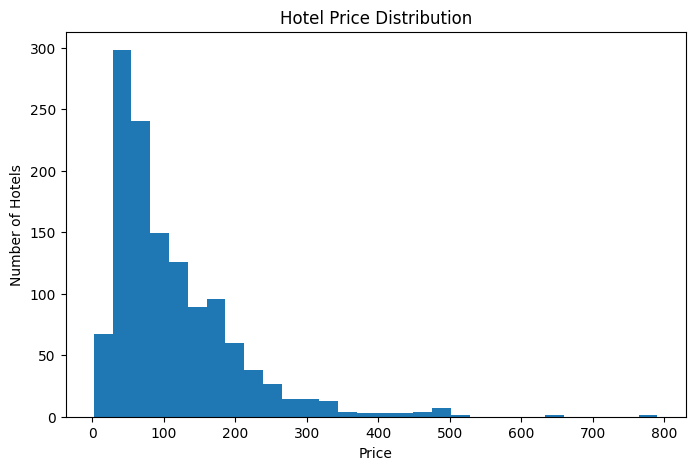

In [5]:
plt.hist(df["price"], bins=30)

plt.title("Hotel Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Hotels")

plt.show()

# Price boxplot

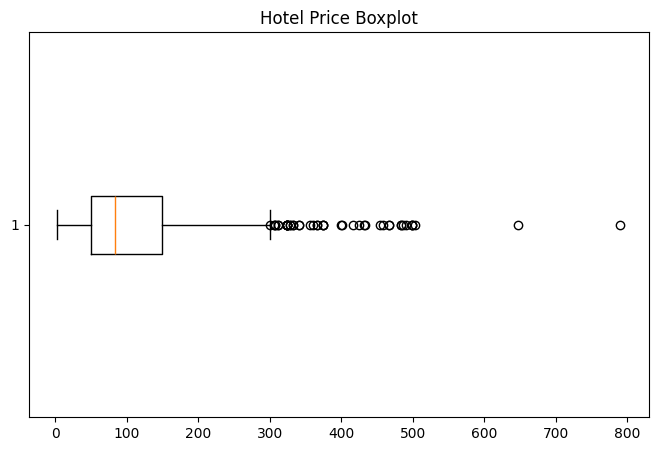

In [6]:
plt.boxplot(df["price"], vert=False)

plt.title("Hotel Price Boxplot")

plt.show()

# Adults distribution

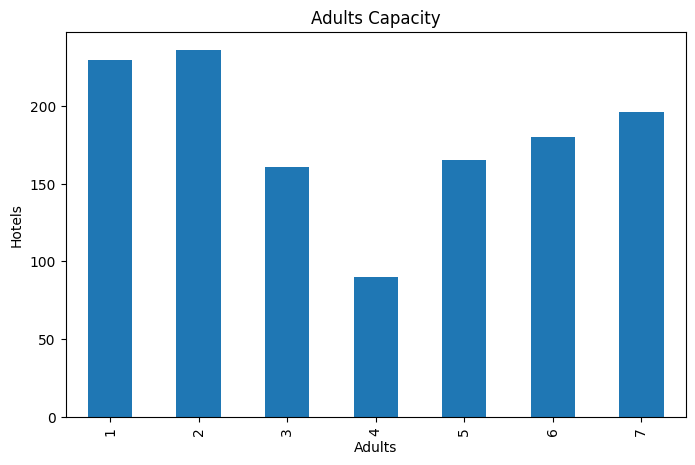

In [7]:
df["adults"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Adults Capacity")
plt.xlabel("Adults")
plt.ylabel("Hotels")

plt.show()

# Distance

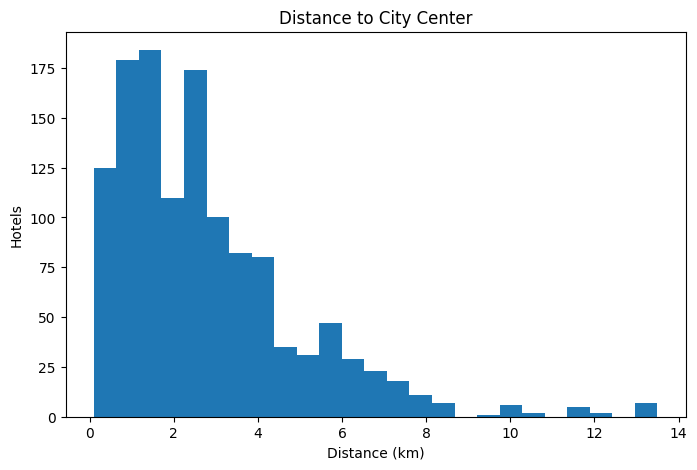

In [8]:
plt.hist(
    df["distance_to_center"],
    bins=25
)

plt.title("Distance to City Center")
plt.xlabel("Distance (km)")
plt.ylabel("Hotels")

plt.show()

# Hotel distribution by city

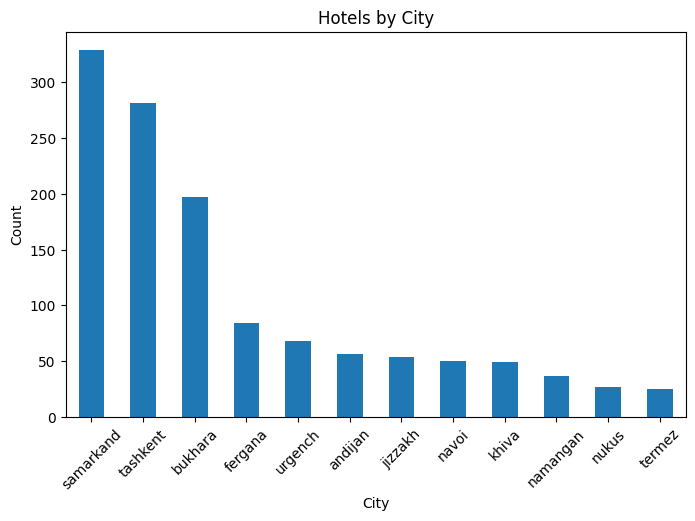

In [9]:
df["city"].value_counts().plot(
    kind="bar"
)

plt.title("Hotels by City")
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Breakfast

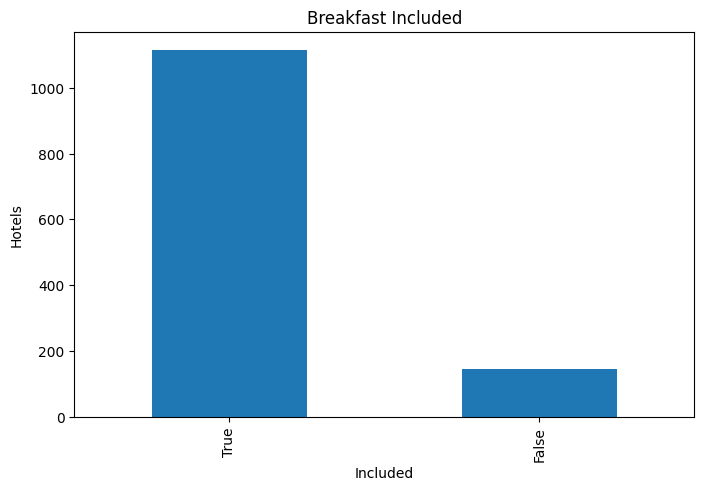

In [10]:
df["bf_has_included"].value_counts().plot(
    kind="bar"
)

plt.title("Breakfast Included")
plt.xlabel("Included")
plt.ylabel("Hotels")

plt.show()

# Price category distribution

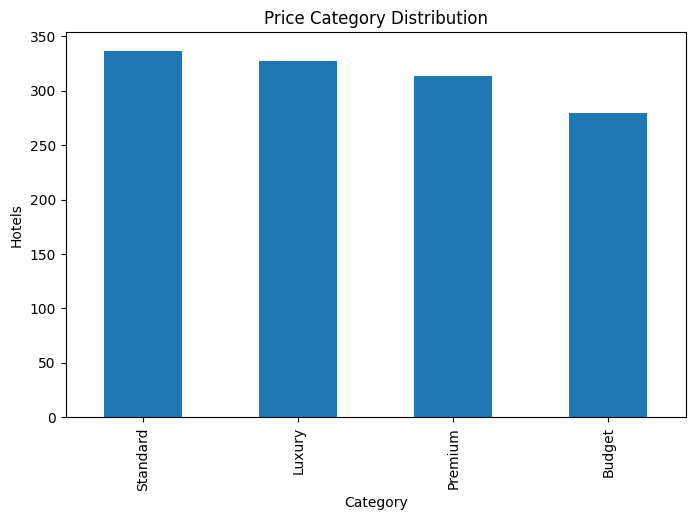

In [11]:
df["price_category"].value_counts().plot(
    kind="bar"
)

plt.title("Price Category Distribution")
plt.xlabel("Category")
plt.ylabel("Hotels")

plt.show()

# Avarage price

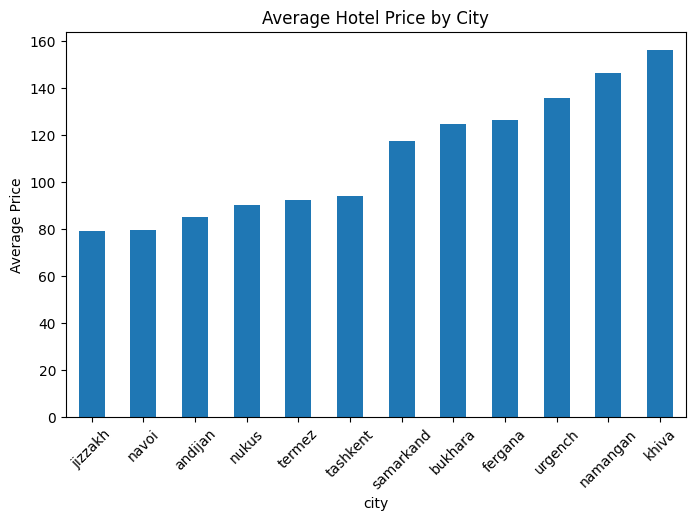

In [12]:
df.groupby("city")["price"].mean().sort_values().plot(
    kind="bar"
)

plt.title("Average Hotel Price by City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

# Breakfast vs price

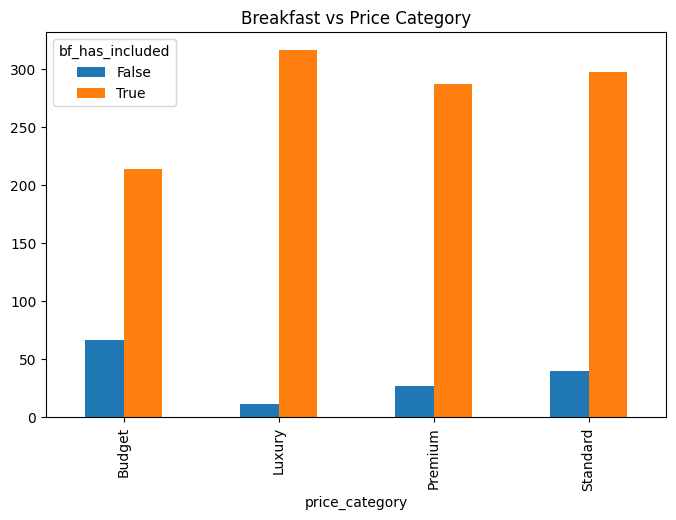

In [13]:
pd.crosstab(
    df["price_category"],
    df["bf_has_included"]
).plot(
    kind="bar"
)

plt.title("Breakfast vs Price Category")

plt.show()

# City vs price

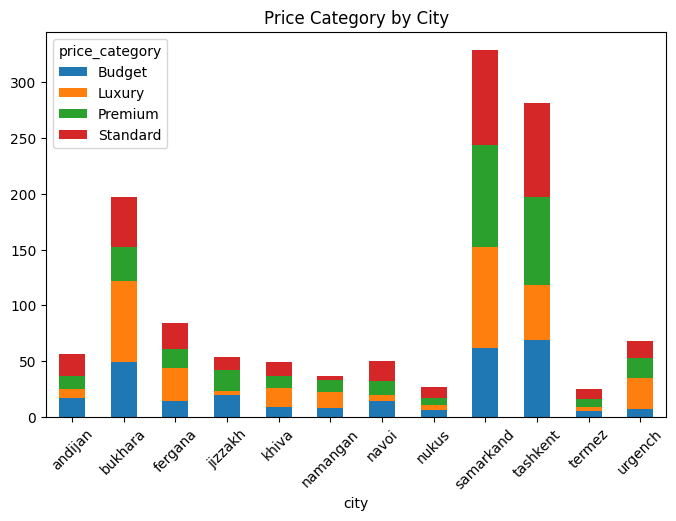

In [14]:
pd.crosstab(
    df["city"],
    df["price_category"]
).plot(
    kind="bar",
    stacked=True
)

plt.title("Price Category by City")

plt.xticks(rotation=45)

plt.show()

# Price vs distance

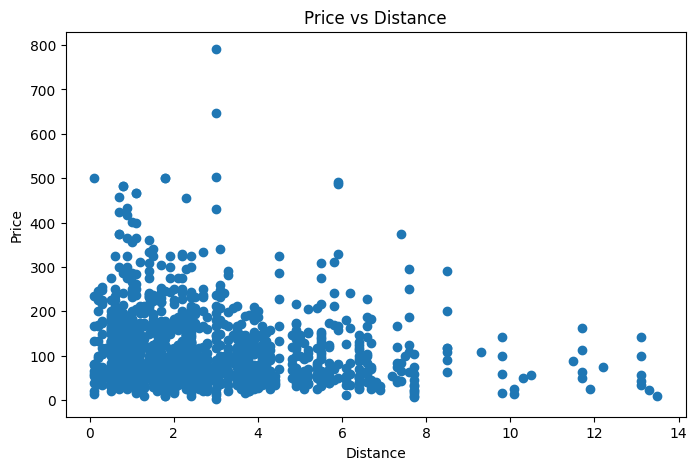

In [16]:
plt.scatter(
    df["distance_to_center"],
    df["price"]
)

plt.xlabel("Distance")
plt.ylabel("Price")

plt.title("Price vs Distance")

plt.show()

# Avarage price by adults

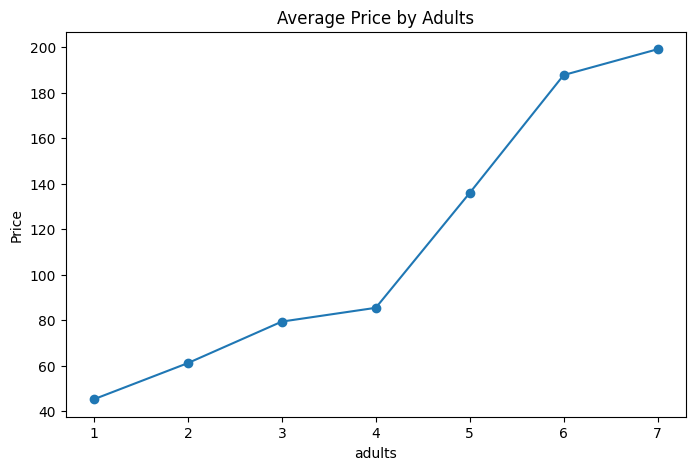

In [17]:
df.groupby("adults")["price"].mean().plot(
    marker="o"
)

plt.title("Average Price by Adults")

plt.ylabel("Price")

plt.show()